<a href="https://colab.research.google.com/github/udayanmaiti2005-maker/Macroeconomic-Structural-Breaks-India/blob/main/Indian_Eco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading

In [ ]:
import pandas as pd
import numpy as np

# Loading the CSV file (using header=0 to correctly identify column names)
filename = '/content/STATEMENT 3.2  GROSS VALUE ADDED BY ECONOMIC ACTIVITY (CONSTANT (2011-12) PRICES).csv'
df = pd.read_csv(filename, header=0)

# Stripping any leading/trailing whitespace
df.columns = df.columns.str.strip()

# Cleaning the 'Year' column (converting '1950-51' to 1951)
df.rename(columns={df.columns[0]: 'Year'}, inplace=True)

# Keep only valid year rows (drop any footnote text at the bottom)
df = df[df['Year'].astype(str).str.contains('-')]
df['Year'] = df['Year'].astype(str).str[:4].astype(int) + 1
df.set_index('Year', inplace=True)

# Convert relevant columns to numeric, handling commas
## Identify columns that are expected to be numeric (excluding 'Year' which is already the index)
numeric_cols = df.columns.drop(['Year'], errors='ignore') # Ensure 'Year' is not included if it was a column

for col in numeric_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce') # Coerce errors to NaN if conversion fails

# 3 Main Variables: Primary, Secondary, Tertiary (Pt, St, Tt) by summing the respective sectors
df['Primary'] = df['Agriculture, Livestock, forestry and fishing'] + df['Mining and quarrying']

df['Secondary'] = df['Manufacturing'] + df['Construction'] + df['Electricity, gas, water supply & other utility services']

df['Tertiary'] = (df['Trade, repair, hotels and restaurants'] +
                  df['Transport, storage, communication & services related to broadcasting'] +
                  df['Financial services'] +
                  df['Real estate, ownership of dwellings & professional services'] +
                  df['Public administration and defence'] +
                  df['Other services'])

df['GDP'] = df['TOTAL GVA']

# Filter the data to match the paper's timeframe (up to 2004)
df = df[['GDP', 'Primary', 'Secondary', 'Tertiary']]
df = df[df.index <= 2004]

# Take the natural logarithm and calculate growth rates (diff of logs * 100) as per the methodology of the paper
for col in ['GDP', 'Primary', 'Secondary', 'Tertiary']:
    df[f'ln_{col}'] = np.log(df[col].astype(float))
    df[f'growth_{col}'] = df[f'ln_{col}'].diff() * 100

# Drop the first year (1951) since it has no prior year to calculate growth from
df.dropna(inplace=True)

# 6. Saving the clean dataset!
df.to_csv('indian_economy_ready_for_regression.csv')

# the first few rows to verify
print("Data successfully cleaned and variables created!")
print(df[['growth_GDP', 'growth_Primary', 'growth_Secondary', 'growth_Tertiary']].head())

Data successfully cleaned and variables created!
      growth_GDP  growth_Primary  growth_Secondary  growth_Tertiary
Year                                                               
1952    2.308043        1.962677          4.552307         2.553935
1953    2.798371        3.064446         -0.447639         2.930858
1954    5.908238        7.133161          5.961857         2.696050
1955    4.157878        2.958095          8.464375         4.140785
1956    2.529051       -0.751281         11.093191         4.330742


In [ ]:
# Installing the required libraries
!pip install statsmodels
!pip install ruptures

# Structural Breaks

------------------------------------------------------------
The Bai-Perron algorithm found a structural break.
The exact structural break year for GDP growth : 1981
------------------------------------------------------------


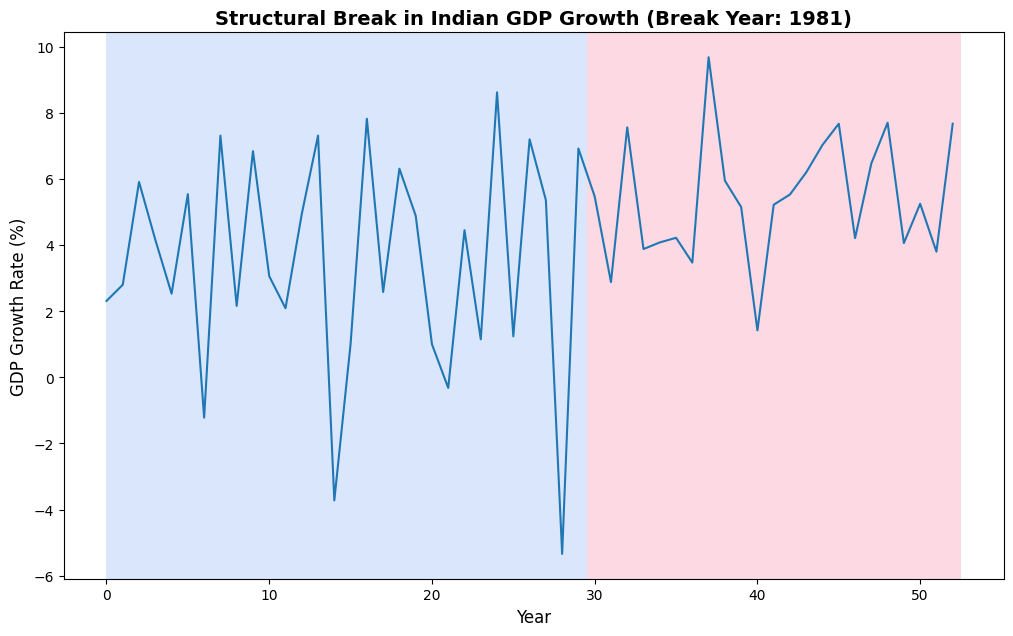

In [ ]:
# Structural Breaks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt

## Load the cleaned dataset
df = pd.read_csv('indian_economy_paper.csv', index_col='Year')

## Extract GDP growth signal for the algorithm
gdp_signal = df['growth_GDP'].values

## Application of Bai-perron Methodology
### The paper tests for shifts in the mean growth rate, so we use model="l2"
### min_size=8 as per the paper (h=8) ensures the algorithm doesn't pick tiny 1-2 year anomalies

algo = rpt.Dynp(model='l2', min_size= 8).fit(gdp_signal)

## Using the algorithm to find exactly 1 major structural break (as per the findings of the paper)
result = algo.predict(n_bkps=1)

## Converting the algorithm's abstract index into years
break_index = result[0] - 1
break_year = df.index[break_index]

print('-' * 60)
print(f'The Bai-Perron algorithm found a structural break.')
print(f'The exact structural break year for GDP growth : {break_year}')
print('-' * 60)

## Generating visual graph
fig, ax_arr = rpt.display(gdp_signal, result, figsize=(10, 6))
plt.title(f'Structural Break in Indian GDP Growth (Break Year: {break_year})', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year', fontsize = 12)
plt.ylabel('GDP Growth Rate (%)', fontsize = 12)
plt.savefig('GDP_Structural_Break_Graph.png', bbox_inches='tight')
plt.show()

# Trend Line

In [ ]:
import plotly.graph_objects as go

# Calculate the AVG GDP growth rate BEFORE and AFTER the break(1981)
mean_regime_1 = df[df.index <= break_year]['growth_GDP'].mean()
mean_regime_2 = df[df.index > break_year]['growth_GDP'].mean()

fig = go.Figure()

# GDP growth line
fig.add_trace(go.Scatter(
    x=df.index, y=df['growth_GDP'],
    mode='lines+markers',
    name='Annual GDP Growth',
    line=dict(color='darkgrey', width=1.5),
    marker=dict(size=4, color='black')
))

# Structural Break line
fig.add_vline(
    x=break_year, line_width=3, line_dash="dot", line_color="red",
    annotation_text=f" Structural Break: {break_year}",
    annotation_position="top left",
    annotation=dict(font_size=12, font_color="red", font_weight = 'bold')
)

# Pre-1981
fig.add_trace(go.Scatter(
    x=[df.index.min(), break_year],
    y=[mean_regime_1, mean_regime_1],
    mode='lines',
    name=f'Pre-{break_year} Average ({mean_regime_1:.2f}%)',
    line=dict(color='blue', width=4)
))

# Post-1981
fig.add_trace(go.Scatter(
    x=[break_year, df.index.max()],
    y=[mean_regime_2, mean_regime_2],
    mode='lines',
    name=f'Post-{break_year} Average ({mean_regime_2:.2f}%)',
    line=dict(color='green', width=4)
))

# Clean up
fig.update_layout(
    title="Structural Break in Indian GDP Growth (Bai-Perron Methodology)",
    xaxis_title="Year",
    yaxis_title="GDP Growth Rate (%)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()
fig.write_html("GDP_Break.html")

# Regression Analysis (Service-sector)

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv('indian_economy_paper.csv', index_col='Year')
df.head()

# Ensuring all columns are treated strictly as numeric data
df = df.apply(pd.to_numeric, errors='coerce')

# 2."Lagged" Variables (t-1 and t-2)
# To test if past sector growth caused current GDP growth, shift the data down by 1 and 2 years.
df['P_t-1'] = df['growth_Primary'].shift(1)
df['S_t-1'] = df['growth_Secondary'].shift(1)
df['T_t-1'] = df['growth_Tertiary'].shift(1)

df['GDP_t-1'] = df['growth_GDP'].shift(1)
df['GDP_t-2'] = df['growth_GDP'].shift(2)

# Replace any hidden infinity values with NaN, then drop ALL NaNs
df.replace([np.inf, -np.inf], np.nan, inplace=True)
reg_df = df.dropna()

# 3. Set up the Regression Model (Matching Table 4, Column 1 of the paper)

## Dependent Variable
Y = reg_df['growth_GDP']

## Explanatory Variables (The independent factors)
X = reg_df[['P_t-1', 'S_t-1', 'T_t-1', 'GDP_t-1', 'GDP_t-2']]

## Constant (intercept) to the mathematical model
X = sm.add_constant(X)

# 4. Ordinary Least Squares (OLS) Regression
model = sm.OLS(Y, X).fit()

print(" REGRESSION SUCCESSFUL: Replicating Table 4 (Dependent Var: GDPt)\n")
print("-" * 75)
print(model.summary())
print("-" * 75)

 REGRESSION SUCCESSFUL: Replicating Table 4 (Dependent Var: GDPt)

---------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:             growth_GDP   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     2.031
Date:                Thu, 13 Aug 2026   Prob (F-statistic):             0.0923
Time:                        03:19:41   Log-Likelihood:                -123.09
No. Observations:                  51   AIC:                             258.2
Df Residuals:                      45   BIC:                             269.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025 

In [ ]:
import statsmodels.api as sm
import numpy as np

# 1. Re-creating the lags, including t-2 for the sectors!
df['P_t-1'] = df['growth_Primary'].shift(1)
df['S_t-1'] = df['growth_Secondary'].shift(1)
df['T_t-1'] = df['growth_Tertiary'].shift(1)

df['P_t-2'] = df['growth_Primary'].shift(2)
df['S_t-2'] = df['growth_Secondary'].shift(2)
df['T_t-2'] = df['growth_Tertiary'].shift(2)

df['GDP_t-1'] = df['growth_GDP'].shift(1)
df['GDP_t-2'] = df['growth_GDP'].shift(2)

# 2. Data Cleaning
df.replace([np.inf, -np.inf], np.nan, inplace=True)
reg_df = df.dropna()

# 3. Full Regression Model (Matching Table 4 perfectly)

## Dependent Variable
Y = reg_df['growth_GDP']

## Explanatory Variable
X = reg_df[['P_t-1', 'S_t-1', 'T_t-1', 'P_t-2', 'S_t-2', 'T_t-2', 'GDP_t-1', 'GDP_t-2']]

##  Adding Constant(intercept)
X = sm.add_constant(X)

# 4. Model FItting
model = sm.OLS(Y, X).fit()

print("REGRESSION SUCCESSFUL: Replicating Table 4 (Dependent Var: GDPt)\n")
print(model.summary())

REGRESSION SUCCESSFUL: Replicating Table 4 (Dependent Var: GDPt)

                            OLS Regression Results                            
Dep. Variable:             growth_GDP   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     1.530
Date:                Thu, 13 Aug 2026   Prob (F-statistic):              0.176
Time:                        03:25:34   Log-Likelihood:                -121.75
No. Observations:                  51   AIC:                             261.5
Df Residuals:                      42   BIC:                             278.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [ ]:
import plotly.graph_objects as go
import pandas as pd

# 1. Exact coefficients generated by the OLS model
data = {
    'Sector': ['Primary (Agriculture)', 'Secondary (Manufacturing)', 'Tertiary (Services)',
               'Primary (2 Yr Lag)', 'Secondary (2 Yr Lag)', 'Tertiary (2 Yr Lag)'],
    'Impact': [-0.1762, 0.0663, 0.5111, -0.2432, -0.2824, -0.0304]
}
coef_df = pd.DataFrame(data)

# Reversing the order so the most important variables appear at the top of the chart
coef_df = coef_df.iloc[::-1]

# 2. Color code: Green for +ve growth, Red for -ve drag
colors = ['crimson' if val < 0 else 'mediumseagreen' for val in coef_df['Impact']]

# 3. Horizontal bar chart
fig = go.Figure(go.Bar(
    x=coef_df['Impact'],
    y=coef_df['Sector'],
    orientation='h',
    marker_color=colors,
    text=[f"{val:.2f}%" for val in coef_df['Impact']],
    textposition='outside',
    textfont=dict(size=14, weight='bold')
))

# Layout Designing
fig.update_layout(
    title=dict(text="Which Sector Drove India's Growth? (Regression Results)", font=dict(size=22)),
    xaxis_title="Impact on GDP (1% increase in the sector causes an X% change in GDP)",
    yaxis_title="",
    xaxis=dict(range=[-0.4, 0.7]),
    template='plotly_white',
    height=500
)

fig.show()
fig.write_html("Regression_Results.html")

In [ ]:
import pandas as pd

# 1. Load your clean dataset
df = pd.read_csv('indian_economy_paper.csv', index_col='Year')

# 2. Define your two eras based on your Bai-Perron finding
break_year = 1981
regime_1 = df[df.index <= break_year]
regime_2 = df[df.index > break_year]

# 3. Calculate overall average GDP growth for both eras
gdp_g1 = regime_1['growth_GDP'].mean()
gdp_g2 = regime_2['growth_GDP'].mean()
delta_gdp_growth = gdp_g2 - gdp_g1

print(f"📈 Overall GDP Growth increased by {delta_gdp_growth:.2f}% (From {gdp_g1:.2f}% to {gdp_g2:.2f}%)\n")

# 4. Calculate Sectoral Contributions
sectors = ['Primary', 'Secondary', 'Tertiary']
contributions = {}

for sector in sectors:
    # A. Calculate the average weight (share of total GDP) for the sector in each era
    w1 = (regime_1[sector] / regime_1['GDP']).mean()
    w2 = (regime_2[sector] / regime_2['GDP']).mean()

    # B. Calculate the average growth rate of the sector in each era
    g1 = regime_1[f'growth_{sector}'].mean()
    g2 = regime_2[f'growth_{sector}'].mean()

    # C. Calculate the sector's total mathematical contribution to the jump in GDP
    # Formula: (Weight_2 * Growth_2) - (Weight_1 * Growth_1)
    sector_delta = (w2 * g2) - (w1 * g1)

    # D. Convert that contribution into a percentage of the total GDP jump
    percent_contribution = (sector_delta / delta_gdp_growth) * 100
    contributions[sector] = percent_contribution

# 5. Print the replicated Table 3
print("-" * 65)
print(" REPLICATED TABLE 3: Sectoral Contribution to Increased GDP Growth")
print(f" (Comparing Pre-{break_year} to Post-{break_year})")
print("-" * 65)

for sector, contrib in contributions.items():
    print(f" {sector} Sector Contribution: \t {contrib:.2f}%")

# Sanity Check: The contributions should add up to roughly 100%
total = sum(contributions.values())
print("-" * 65)
print(f" Total Accounted For: \t\t {total:.2f}%")
print("-" * 65)

📈 Overall GDP Growth increased by 1.92% (From 3.50% to 5.42%)

-----------------------------------------------------------------
 REPLICATED TABLE 3: Sectoral Contribution to Increased GDP Growth
 (Comparing Pre-1981 to Post-1981)
-----------------------------------------------------------------
 Primary Sector Contribution: 	 -3.15%
 Secondary Sector Contribution: 	 18.57%
 Tertiary Sector Contribution: 	 81.51%
-----------------------------------------------------------------
 Total Accounted For: 		 96.94%
-----------------------------------------------------------------


In [ ]:
import pandas as pd

df = pd.read_csv('indian_economy_paper.csv', index_col='Year')

# Define two eras based on Bai-Perron finding
break_year = 1981
regime_1 = df[df.index <= break_year]
regime_2 = df[df.index > break_year]

# Calculate overall average GDP growth for both eras
gdp_g1 = regime_1['growth_GDP'].mean()
gdp_g2 = regime_2['growth_GDP'].mean()
delta_gdp_growth = gdp_g2 - gdp_g1

print(f"📈 Overall GDP Growth increased by {delta_gdp_growth:.2f}% (From {gdp_g1:.2f}% to {gdp_g2:.2f}%)\n")

# Calculate Sectoral Contributions
sectors = ['Primary', 'Secondary', 'Tertiary']
contributions = {}

for sector in sectors:
    # A. Calculate the average weight (share of total GDP) for the sector in each era
    w1 = (regime_1[sector] / regime_1['GDP']).mean()
    w2 = (regime_2[sector] / regime_2['GDP']).mean()

    # B. Calculate the average growth rate of the sector in each era
    g1 = regime_1[f'growth_{sector}'].mean()
    g2 = regime_2[f'growth_{sector}'].mean()

    # C. Calculate the sector's total mathematical contribution to the jump in GDP
    # Formula: (Weight_2 * Growth_2) - (Weight_1 * Growth_1)
    sector_delta = (w2 * g2) - (w1 * g1)

    # D. Convert that contribution into a percentage of the total GDP jump
    percent_contribution = (sector_delta / delta_gdp_growth) * 100
    contributions[sector] = percent_contribution

# --- NORMALIZATION ---
## Find the sum of our raw calculated contributions
raw_total = sum(contributions.values())

## Divide each sector by the raw total to force them into a 100% scale
normalized_contributions = {sector: (val / raw_total) * 100 for sector, val in contributions.items()}

# Print the replicated Table 3
print("-" * 65)
print("Sectoral Contribution to Increased GDP Growth")
print(f" (Comparing Pre-{break_year} to Post-{break_year})")
print("-" * 65)

for sector, contrib in normalized_contributions.items():
    print(f" {sector} Sector Contribution: \t {contrib:.2f}%")

# The contributions should now add up exactly to 100.00%
total = sum(normalized_contributions.values())
print("-" * 65)
print(f" Total Accounted For: \t\t {total:.2f}%")
print("-" * 65)

📈 Overall GDP Growth increased by 1.92% (From 3.50% to 5.42%)

-----------------------------------------------------------------
Sectoral Contribution to Increased GDP Growth
 (Comparing Pre-1981 to Post-1981)
-----------------------------------------------------------------
 Primary Sector Contribution: 	 -3.25%
 Secondary Sector Contribution: 	 19.16%
 Tertiary Sector Contribution: 	 84.09%
-----------------------------------------------------------------
 Total Accounted For: 		 100.00%
-----------------------------------------------------------------


In [ ]:
import plotly.graph_objects as go

sectors = ['Primary (Agriculture)', 'Secondary (Manufacturing)', 'Tertiary (Services)']
contributions = [-3.25, 19.16, 84.09]

# Color code the bars (Red for -ve/drag, Green for +ve/growth)
colors = ['crimson' if val < 0 else 'mediumseagreen' for val in contributions]

# Diverging Bar Chart
fig = go.Figure(go.Bar(
    x=contributions,
    y=sectors,
    orientation='h',
    marker_color=colors,
    text=[f"{val:.2f}%" for val in contributions],
    textposition=['outside' if val < 0 else 'inside' for val in contributions],
    textfont=dict(size=16, color='white')
))

# Annotations for the Presentation
fig.add_annotation(
    x=84.09, y='Tertiary (Services)',
    text="The Services-Led Growth Domination",
    showarrow=True, arrowhead=2, ax=20, ay=-50,
    font=dict(size=14, color="mediumseagreen", weight="bold")
)

fig.add_annotation(
    x=-3.25, y='Primary (Agriculture)',
    text="Agriculture's share of overall GDP shrank",
    showarrow=True, arrowhead=2, ax=145, ay=20,
    font=dict(size=12, color="crimson")
)

# 5. Clean up the layout
fig.update_layout(
    title=dict(text="Decomposition of Growth: What Drove the 1981 Boom?", font=dict(size=22)),
    xaxis_title="Contribution to GDP Acceleration (%)",
    yaxis_title="",
    shapes=[dict(type="line", x0=0, x1=0, y0=-0.5, y1=2.5, line=dict(color="black", width=2))],
    xaxis=dict(range=[-10, 100]),
    template="plotly_white",
    height=500
)

fig.show()
fig.write_html("Sectoral_Contribution.html")